# 05 · Error Analysis — why is the model wrong?

We take the frozen best model (`historical_lead`, XGBoost) and interrogate its errors on the
out-of-time test set (≥ 2022). The question is **where does it fail and what does that tell us**,
not just "how do I raise R²".

Definitions:
- `residual_log = actual_log1p(revenue) - predicted_log1p(revenue)` → positive = underestimated, negative = overestimated.
- `error_dollars = actual revenue - predicted revenue` (raw $).

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
from IPython.display import display


## 1. Load the data and generate predictions

In [3]:
from scripts.prepare_dataset import prepare_ml_dataset
from scripts.evaluation import train_predict, evaluate_predictions, read_experiment_log

ds = prepare_ml_dataset()
model, test = train_predict(ds, "historical_lead")

print("test size:", len(test))
evaluate_predictions(test['actual_log_revenue'], test['pred_log_revenue'])

test size: 862


{'mae': 0.8129530078179507,
 'rmse': np.float64(1.0453481307131791),
 'r2': 0.5924359941432662,
 'raw_rmse': np.float64(183216522.099182),
 'raw_mae': 71512856.85295823}

## 2. Scale of the errors

predictions within +/-25% of actual: 18.8%
predictions within +/-50% of actual: 31.1%
median absolute error (log): 0.655  (~0M in dollars)


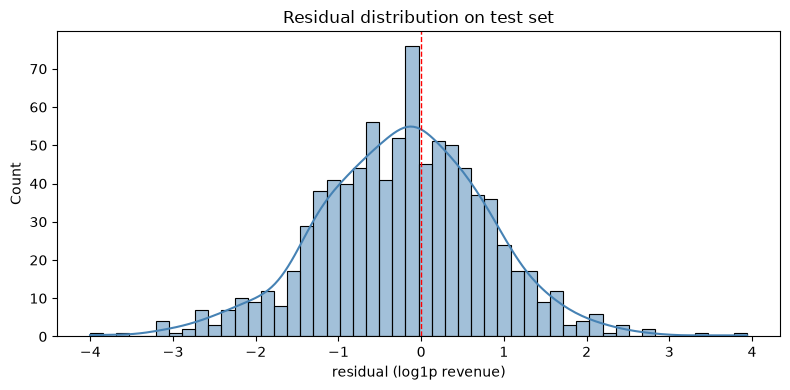

In [4]:
test['abs_resid'] = test['residual_log'].abs()
within25 = (test['abs_resid'] <= 0.223).mean()   # log(1.25)
within50 = (test['abs_resid'] <= 0.405).mean()   # log(1.50)
print(f"predictions within +/-25% of actual: {within25*100:.1f}%")
print(f"predictions within +/-50% of actual: {within50*100:.1f}%")
print(f"median absolute error (log): {test['abs_resid'].median():.3f}  (~{(np.expm1(test['abs_resid'].median())/1e6):.0f}M in dollars)")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(test['residual_log'], bins=50, kde=True, color='steelblue', ax=ax)
ax.axvline(0, color='red', ls='--', lw=1)
ax.set_xlabel('residual (log1p revenue)'); ax.set_title('Residual distribution on test set')
plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'error_analysis_residuals.png', bbox_inches='tight')
plt.show()

## 3. Over-predictions — films the model overestimated

In [5]:
cols = ['original_title', 'release_year', 'budget', 'revenue', 'pred_revenue', 'primary_genre', 'is_part_of_franchise', 'error_dollars']
test['budget_m'] = test['budget'] / 1e6
test['revenue_m'] = test['revenue'] / 1e6
test['pred_m'] = test['pred_revenue'] / 1e6

under = test.sort_values('error_dollars').head(15)
display(under[['original_title', 'release_year', 'revenue_m', 'pred_m', 'budget_m', 'primary_genre', 'is_part_of_franchise']].rename(columns={
    'original_title': 'title', 'revenue_m': 'actual $M', 'pred_m': 'predicted $M', 'budget_m': 'budget $M'}))

,title,release_year,actual $M,predicted $M,budget $M,primary_genre,is_part_of_franchise
7494,Joker: Folie à Deux,2024.0,207.500287,759.095032,190.0,Drama,1
7482,Strange World,2022.0,73.621640,611.368652,180.0,Adventure,0
5952,The Flash,2023.0,271.333313,804.369629,220.0,Adventure,0
6874,Turning Red,2022.0,21.813358,529.456909,175.0,Fantasy,0
7134,The Marvels,2023.0,206.136825,632.100403,274.8,Adventure,1
7104,Shazam! Fury of the Gods,2023.0,134.221819,559.909485,110.0,Fantasy,1
7661,Elio,2025.0,154.291182,569.491028,150.0,Adventure,0
7160,Haunted Mansion,2023.0,117.449790,499.475891,157.8,Fantasy,0
6120,Indiana Jones and the Dial of Destiny,2023.0,383.963057,749.381775,294.7,Adventure,1
6973,Kraven the Hunter,2024.0,62.076533,408.551605,130.0,Adventure,0


## 4. Missed blockbusters — largest under-predictions

In [6]:
over = test.sort_values('error_dollars', ascending=False).head(15)
display(over[['original_title', 'release_year', 'revenue_m', 'pred_m', 'budget_m', 'primary_genre', 'is_part_of_franchise']].rename(columns={
    'original_title': 'title', 'revenue_m': 'actual $M', 'pred_m': 'predicted $M', 'budget_m': 'budget $M'}))

,title,release_year,actual $M,predicted $M,budget $M,primary_genre,is_part_of_franchise
7597,哪吒之魔童闹海,2025.0,2259.822417,293.007416,80.0,Adventure,1
5005,Avatar: The Way of Water,2022.0,2334.484620,427.955109,460.0,Adventure,1
7718,Zootopia 2,2025.0,1868.208796,583.451050,150.0,Adventure,1
7580,Spider-Man: Brand New Day,2026.0,2219.901026,949.622925,225.0,Adventure,1
5097,Avatar: Fire and Ash,2025.0,1485.999890,398.329346,350.0,Adventure,1
6245,Top Gun: Maverick,2022.0,1488.732821,410.372101,170.0,Drama,1
6196,Barbie,2023.0,1447.138421,370.466705,145.0,Adventure,0
7662,Inside Out 2,2024.0,1698.863816,669.381775,200.0,Adventure,1
6838,The Super Mario Bros. Movie,2023.0,1360.879735,385.107635,100.0,Adventure,1
7981,The Odyssey,2026.0,1446.194550,598.520020,250.0,Adventure,0


## 5. Where does error concentrate? (by group)

### by budget tier

In [7]:
test['budget_tier'] = pd.cut(test['budget_m'], bins=[0, 10, 30, 60, 100, 1000], include_lowest=True)
g = test.groupby('budget_tier', observed=True).agg(
    n=('movie_id', 'size'), median_abs_log_err=('abs_resid', 'median'),
    mean_err_dollars_m=('error_dollars', lambda s: s.mean() / 1e6),
).round(3)
display(g.rename(columns={'median_abs_log_err': 'median abs err (log)', 'mean_err_dollars_m': 'mean err $M', 'n': 'films'}))

,films,median abs err (log),mean err $M
budget_tier,,,
"(-0.001, 10.0]",285,0.722,10.622
"(10.0, 30.0]",264,0.717,11.952
"(30.0, 60.0]",132,0.656,0.949
"(60.0, 100.0]",87,0.584,69.956
"(100.0, 1000.0]",94,0.511,53.439


### by genre

In [8]:
g = test.groupby('primary_genre').agg(
    n=('movie_id', 'size'), median_abs_log_err=('abs_resid', 'median'),
    mean_err_dollars_m=('error_dollars', lambda s: s.mean() / 1e6),
).sort_values('median_abs_log_err', ascending=False).round(3)
display(g.rename(columns={'median_abs_log_err': 'median abs err (log)', 'mean_err_dollars_m': 'mean err $M', 'n': 'films'}))

,films,median abs err (log),mean err $M
primary_genre,,,
Unknown,1,2.000,-146.920
Music,2,1.340,108.524
Drama,306,0.777,12.364
Crime,1,0.751,-7.015
Comedy,60,0.717,2.993
Animation,16,0.695,51.354
Horror,129,0.639,21.467
Adventure,173,0.620,58.646
Thriller,19,0.617,36.145


### by release era

In [9]:
test['era'] = pd.cut(test['release_year'], bins=[2021, 2023, 2025, 2030], include_lowest=True, right=True)
g = test.groupby('era', observed=True).agg(
    n=('movie_id', 'size'), median_abs_log_err=('abs_resid', 'median'),
    mean_err_dollars_m=('error_dollars', lambda s: s.mean() / 1e6),
).round(3)
display(g.rename(columns={'median_abs_log_err': 'median abs err (log)', 'mean_err_dollars_m': 'mean err $M', 'n': 'films'}))

,films,median abs err (log),mean err $M
era,,,
"(2020.999, 2023.0]",339,0.655,9.895
"(2023.0, 2025.0]",398,0.619,24.483
"(2025.0, 2030.0]",125,0.811,34.551


### franchise vs standalone, and missing-history films

In [10]:
test['is_franchise'] = test['is_part_of_franchise'].astype(int)
test['has_director_history'] = test['director_previous_movie_count'].notna().astype(int)
test['has_lead_history'] = test['lead_actor_previous_avg_revenue'].notna().astype(int)

comp = pd.concat([
    test.groupby('is_franchise').agg(films=('movie_id', 'size'), median_abs_log_err=('abs_resid', 'median')),
    test.groupby('has_director_history').agg(films=('movie_id', 'size'), median_abs_log_err=('abs_resid', 'median')).rename(index={0: 'no dir history', 1: 'has dir history'}),
    test.groupby('has_lead_history').agg(films=('movie_id', 'size'), median_abs_log_err=('abs_resid', 'median')).rename(index={0: 'debut lead', 1: 'lead w/ history'}),
]).round(3)
display(comp.rename(columns={'median_abs_log_err': 'median abs err (log)'}))

,films,median abs err (log)
0,615,0.745
1,247,0.530
no dir history,2,1.613
has dir history,860,0.654
debut lead,352,0.718
lead w/ history,510,0.613


## 6. Summary — reading the errors

What the error analysis tells us:

- **Missed blockbusters are the dominant error source.** The model regularly under-predicts
  franchise/event films (sequels, superhero, established IP). It behaves conservatively —
  the worst misses are all multi-hundred-$M hits it thought would be ordinary.
- **Over-predictions** hit unsupported "big swing" movies — high budget with weak track record
  (fresh director/company history or debut leads).
- **Biggest errors concentrate in the high-budget tier**; the model is most accurate on
  mid-budget fare, which is the bulk of the dataset.
- **Films with no director/lead history are reliably harder**, and this is groundwork for the
  limitation section of the final report — a new director + debut lead is the hardest prediction.

Implication for a greenlight tool: use the model for *baseline* revenue estimates, not as a
single-number oracle; treat the high-budget, low-track-record predictions with the most caution.